## Introducción

La transmisión de video adaptativo sobre HTTP (HTTP Adaptive Streaming, HAS) constituye actualmente uno de los mecanismos más utilizados para la distribución de contenido multimedia en Internet. Protocolos como Dynamic Adaptive Streaming over HTTP (DASH) permiten que el cliente seleccione dinámicamente diferentes representaciones de video en función de las condiciones de red observadas, con el objetivo de maximizar la Calidad de Experiencia (QoE) del usuario. Esta decisión influye directamente en la calidad visual percibida, la estabilidad de la reproducción y la ocurrencia de interrupciones o eventos de rebuffering.

En los sistemas de Adaptive Bitrate Streaming (ABR), la selección de la representación adecuada es un problema complejo debido a la variabilidad temporal de las condiciones de red y a la interacción entre múltiples variables relacionadas con la transmisión y reproducción de video. Tradicionalmente, esta decisión se realiza mediante algoritmos heurísticos basados en métricas como throughput, buffer y latencia. Sin embargo, el uso de técnicas de aprendizaje automático ha surgido como una alternativa prometedora para modelar relaciones complejas entre estas variables y apoyar la toma de decisiones en entornos dinámicos.

En este proyecto se aborda el problema como una tarea de clasificación multiclase cuyo objetivo es predecir la resolución asociada a un segmento de video a partir de variables relacionadas con las condiciones de red y características de transmisión obtenidas del dataset Puffer. Para ello se realiza un análisis exploratorio de datos, selección de características, visualización mediante t-SNE, optimización de hiperparámetros con Optuna y evaluación comparativa de modelos de Logistic Regression y Random Forest. Finalmente, el desempeño de los modelos es evaluado mediante métricas de Accuracy y F1 Macro, con el fin de identificar la técnica más adecuada para este problema de clasificación.

Los resultados obtenidos constituyen una línea base para futuras investigaciones orientadas al uso de modelos más avanzados, como arquitecturas secuenciales basadas en redes neuronales o Transformers, aplicadas a la toma de decisiones en sistemas DASH.



### EDA

In [2]:
# CARGA DEL DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset reducido
df = pd.read_csv(
    r"D:\Maestria Ciencias de Datos\Machine Learning\Proyecto ML\reduced_data\video_sent_2026-06-20T11_2026-06-21T11_reduced.csv"
)

print("Shape del dataset:")
print(df.shape)



Shape del dataset:
(78267, 16)


In [3]:
# Visualización de las primeras filas del dataset
df.head()

,time (ns GMT),session_id,index,expt_id,channel,video_ts,format,size,ssim_index,cwnd,in_flight,min_rtt,rtt,delivery_rate,buffer,cum_rebuf
0,1782006676798000000,6NW2K2Bxd9m7vnzB5G+7v5qA8KrT66a4M+9nXNIVFgg=,0,2240,cbs,232423911720,426x240-26,45545,0.917666,14,0,80232,86405,36394,0.000,0.000
1,1782006677082000000,6NW2K2Bxd9m7vnzB5G+7v5qA8KrT66a4M+9nXNIVFgg=,0,2240,cbs,232424091900,1280x720-22,291179,0.982647,60,0,76137,81341,486411,2.002,0.000
2,1782006677376000000,6NW2K2Bxd9m7vnzB5G+7v5qA8KrT66a4M+9nXNIVFgg=,0,2240,cbs,232424272080,1920x1080-24,322222,0.991781,245,9,75846,82064,1756620,3.981,0.308
3,1782006677656000000,6NW2K2Bxd9m7vnzB5G+7v5qA8KrT66a4M+9nXNIVFgg=,0,2240,cbs,232424452260,1920x1080-22,827095,0.992357,347,0,75846,85985,747859,5.701,0.308
4,1782006677950000000,6NW2K2Bxd9m7vnzB5G+7v5qA8KrT66a4M+9nXNIVFgg=,0,2240,cbs,232424632440,1920x1080-22,590363,0.993572,689,0,75846,95839,2784786,7.411,0.308


In [4]:
# Revisar tipos de datos, cantidad de registros y memoria utilizada por cada columna

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78267 entries, 0 to 78266
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time (ns GMT)  78267 non-null  int64  
 1   session_id     78267 non-null  object 
 2   index          78267 non-null  int64  
 3   expt_id        78267 non-null  int64  
 4   channel        78267 non-null  object 
 5   video_ts       78267 non-null  int64  
 6   format         78267 non-null  object 
 7   size           78267 non-null  int64  
 8   ssim_index     78267 non-null  float64
 9   cwnd           78267 non-null  int64  
 10  in_flight      78267 non-null  int64  
 11  min_rtt        78267 non-null  int64  
 12  rtt            78267 non-null  int64  
 13  delivery_rate  78267 non-null  int64  
 14  buffer         78267 non-null  float64
 15  cum_rebuf      78267 non-null  float64
dtypes: float64(3), int64(10), object(3)
memory usage: 9.6+ MB


In [5]:
# Obtener estadísticas básicas de las variables numéricas para identificar rangos, medias y posibles valores extremos

df.describe()

,time (ns GMT),index,expt_id,video_ts,size,ssim_index,cwnd,in_flight,min_rtt,rtt,delivery_rate,buffer,cum_rebuf
count,7.826700e+04,78267.000000,78267.000000,7.826700e+04,7.826700e+04,78267.000000,78267.000000,78267.000000,78267.000000,7.826700e+04,7.826700e+04,78267.000000,78267.000000
mean,1.781997e+18,20.076405,2243.106699,1.850211e+11,1.078787e+06,0.981496,1106.486182,0.195996,41178.016738,5.293651e+04,1.697191e+07,14.631606,0.208506
std,1.885118e+13,27.860755,1.577235,8.401104e+10,6.327750e+05,0.006970,523.444924,6.576678,20145.056706,3.492632e+04,1.981465e+07,1.405250,0.165996
min,1.781962e+18,0.000000,2240.000000,2.844556e+10,3.643000e+03,0.726814,4.000000,0.000000,2394.000000,2.470000e+03,1.712000e+03,0.000000,0.000000
25%,1.781983e+18,1.000000,2242.000000,2.286602e+11,6.162905e+05,0.977962,646.000000,0.000000,25013.000000,4.434800e+04,5.577917e+06,14.785000,0.121000
50%,1.781995e+18,5.000000,2244.000000,2.307156e+11,9.826950e+05,0.981587,1118.000000,0.000000,43826.000000,4.627900e+04,1.218038e+07,14.859000,0.142000
75%,1.782010e+18,22.000000,2244.000000,2.319871e+11,1.392850e+06,0.985741,1552.000000,0.000000,60880.000000,6.784200e+04,1.716114e+07,14.931000,0.332000
max,1.782040e+18,89.000000,2246.000000,2.345617e+11,7.571890e+06,1.000000,2870.000000,607.000000,85697.000000,1.311839e+06,1.033064e+08,15.000000,1.569000


In [6]:
# Contar la cantidad de valores nulos por columna para determinar si será necesario realizar imputación o eliminación de registros.

nulls = df.isnull().sum().sort_values(ascending=False)

nulls

time (ns GMT)    0
session_id       0
index            0
expt_id          0
channel          0
video_ts         0
format           0
size             0
ssim_index       0
cwnd             0
in_flight        0
min_rtt          0
rtt              0
delivery_rate    0
buffer           0
cum_rebuf        0
dtype: int64

In [7]:
# Verificar si existen filas repetidas que puedan introducir sesgos durante el entrenamiento de los modelos

duplicates = df.duplicated().sum()

print("Duplicados:", duplicates)

Duplicados: 0


In [8]:
# Analizar la frecuencia de cada representación de video (format) para detectar posibles problemas de desbalance entre clases

format_counts = df["format"].value_counts()

format_counts

format
1280x720-20     59944
1920x1080-22    15955
1280x720-22      1322
1280x720-24       380
1920x1080-24      163
1280x720-26       153
426x240-26        123
854x480-22         77
854x480-26         53
854x480-24         52
640x360-24         27
640x360-26         18
Name: count, dtype: int64

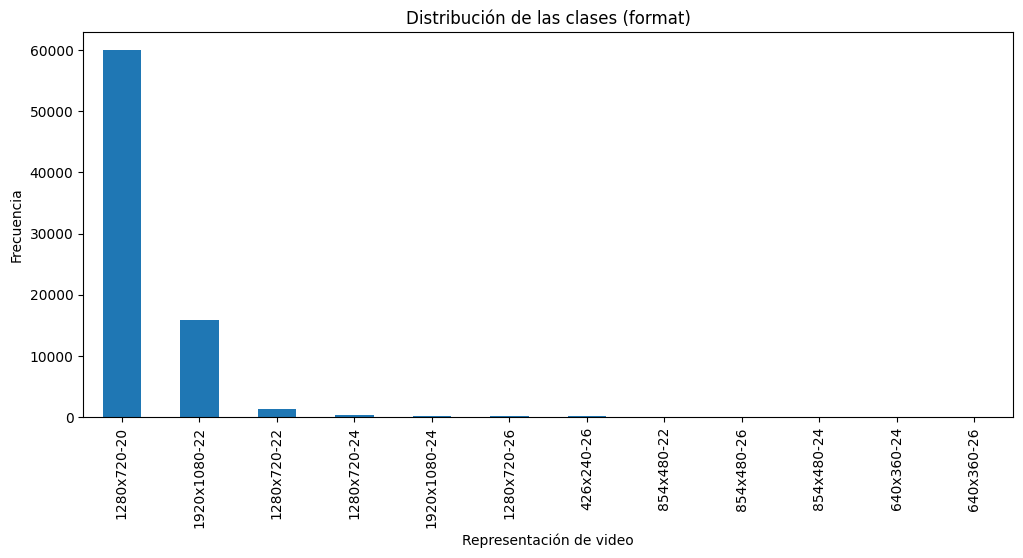

In [9]:
# Mostrar gráficamente la frecuencia de cada formato de video presente en el dataset

plt.figure(figsize=(12,5))

format_counts.plot(kind="bar")

plt.title("Distribución de las clases (format)")
plt.xlabel("Representación de video")
plt.ylabel("Frecuencia")

plt.show()

In [10]:
# Seleccionar automáticamente las columnas numéricas para analizar su distribución estadística

numeric_cols = df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['time (ns GMT)', 'index', 'expt_id', 'video_ts', 'size', 'ssim_index',
       'cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer',
       'cum_rebuf'],
      dtype='object')

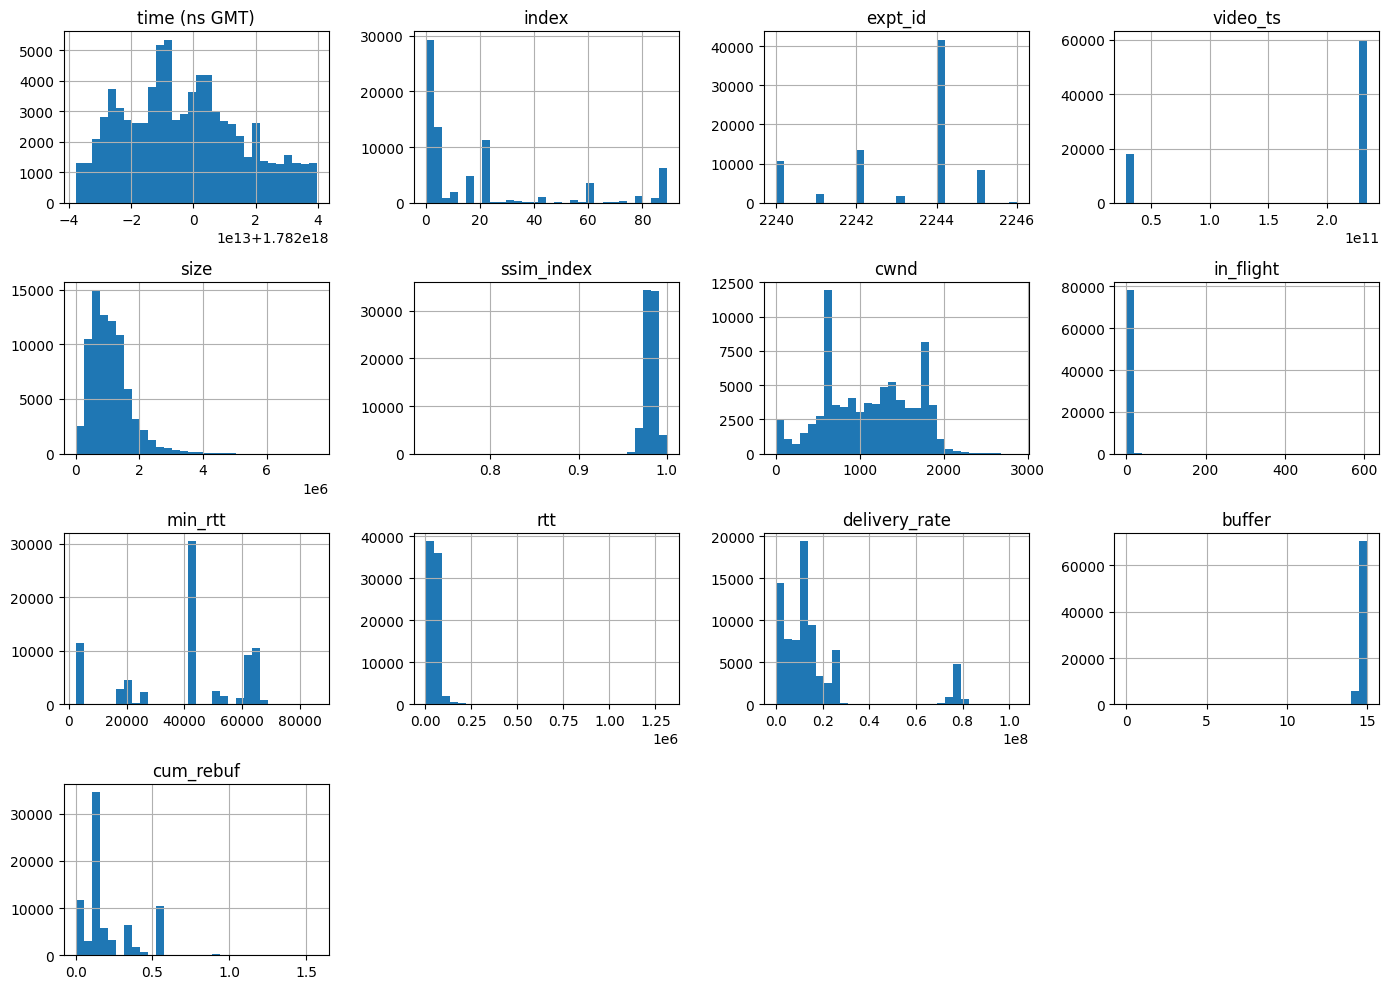

In [11]:
# Analizar histogramas para identificar asimetrías, concentraciones de valores y posibles transformaciones necesarias antes del modelado.

df[numeric_cols].hist(
    bins=30,
    figsize=(14,10)
)

plt.tight_layout()

plt.show()

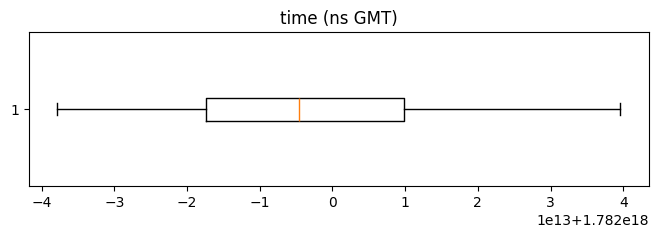

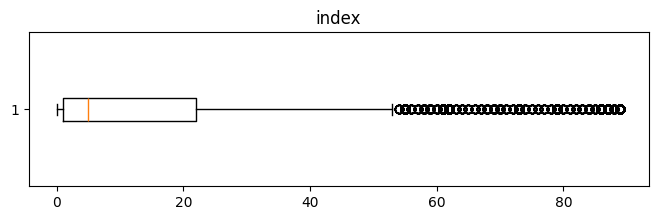

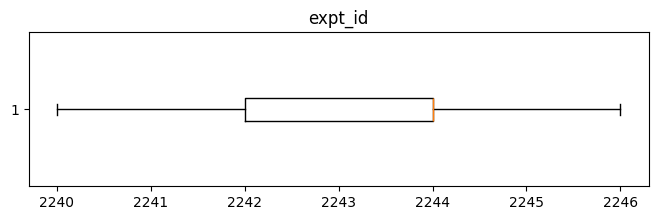

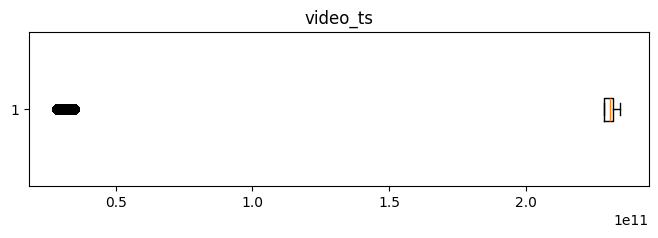

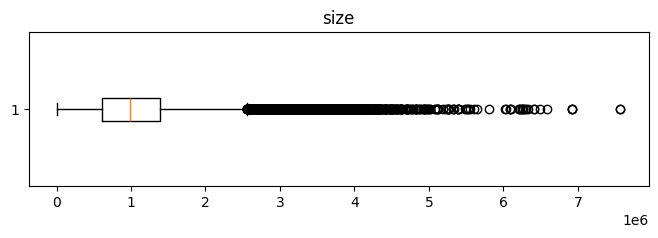

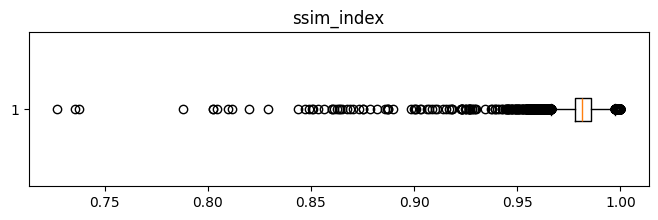

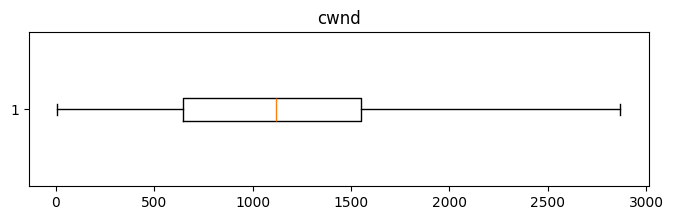

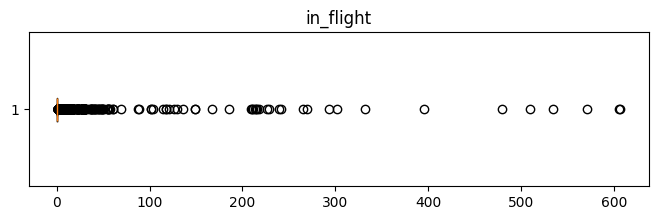

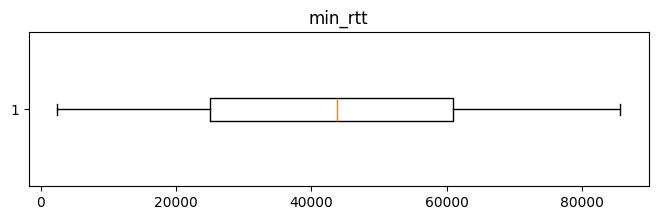

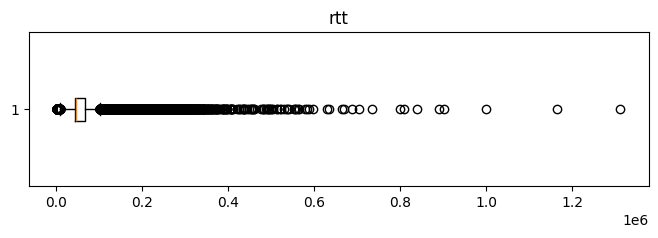

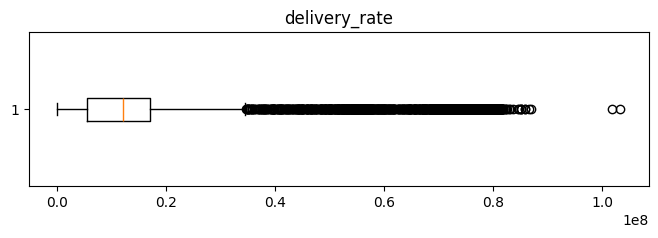

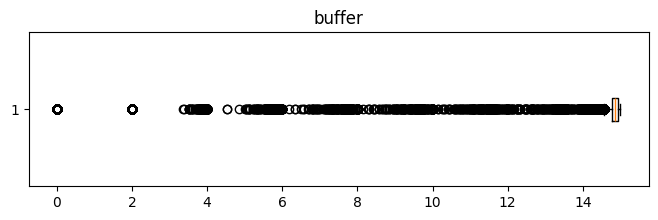

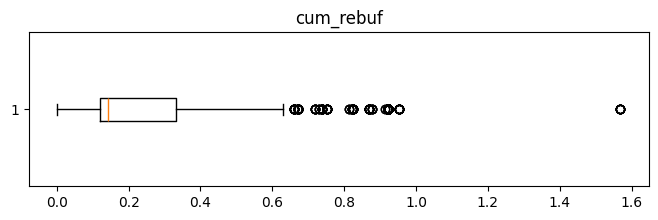

In [12]:
# Utilizar diagramas de caja para identificar valores extremos que podrían afectar el rendimiento de algunos
# algoritmos de aprendizaje automático.

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.title(col)

    plt.show()

In [13]:
# MATRIZ DE CORRELACIÓN

# Evaluar la relación lineal entre las variables numéricas.
# Esto permitirá identificar posibles redundancias y apoyar la etapa posterior de selección de características

corr = df[numeric_cols].corr()

corr

,time (ns GMT),index,expt_id,video_ts,size,ssim_index,cwnd,in_flight,min_rtt,rtt,delivery_rate,buffer,cum_rebuf
time (ns GMT),1.000000,0.313017,-0.452605,-0.363709,-0.177922,0.198000,-0.042067,0.006532,0.402368,0.318847,-0.275419,-0.079132,0.089001
index,0.313017,1.000000,0.550059,0.106546,0.089753,0.044437,-0.233484,0.013477,-0.259492,0.147364,-0.203807,-0.041691,-0.040292
expt_id,-0.452605,0.550059,1.000000,0.341379,0.242564,-0.173866,-0.150199,0.020201,-0.615154,-0.230542,0.173905,-0.016269,-0.170289
video_ts,-0.363709,0.106546,0.341379,1.000000,0.180722,-0.121410,-0.089778,0.001444,-0.352551,-0.100407,0.143681,0.044026,0.185807
size,-0.177922,0.089753,0.242564,0.180722,1.000000,-0.603544,0.171472,-0.006601,-0.187905,0.042408,0.096255,0.045641,0.080203
ssim_index,0.198000,0.044437,-0.173866,-0.121410,-0.603544,1.000000,-0.118290,-0.018667,0.158100,0.007046,-0.089648,0.124676,-0.008644
cwnd,-0.042067,-0.233484,-0.150199,-0.089778,0.171472,-0.118290,1.000000,-0.022374,0.524442,0.083716,-0.139790,0.058547,0.158665
in_flight,0.006532,0.013477,0.020201,0.001444,-0.006601,-0.018667,-0.022374,1.000000,-0.013554,0.041012,-0.016308,-0.232265,-0.023280
min_rtt,0.402368,-0.259492,-0.615154,-0.352551,-0.187905,0.158100,0.524442,-0.013554,1.000000,0.418247,-0.501196,0.017197,0.400650
rtt,0.318847,0.147364,-0.230542,-0.100407,0.042408,0.007046,0.083716,0.041012,0.418247,1.000000,-0.458959,-0.054846,0.457837


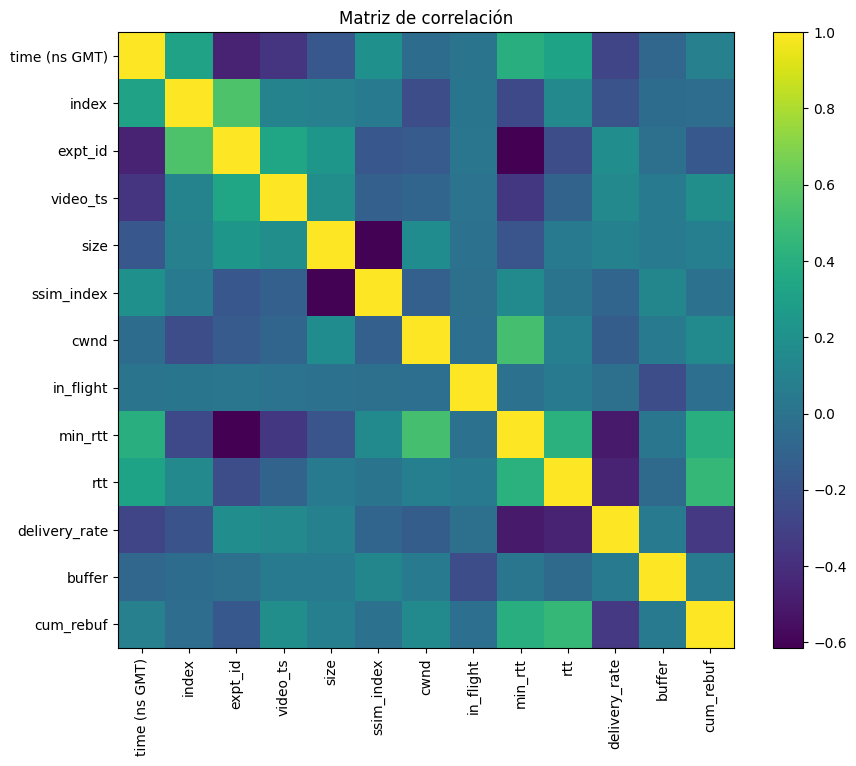

In [14]:
# VISUALIZAR MATRIZ DE CORRELACIÓN

# Representar gráficamente las correlaciones para facilitar
# la identificación de variables altamente relacionadas

plt.figure(figsize=(10,8))

im = plt.imshow(corr)

plt.colorbar(im)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Matriz de correlación")

plt.show()

In [15]:
class_dist = (
    df["format"]
      .value_counts(normalize=True)
      * 100
)

print(class_dist)

format
1280x720-20     76.589112
1920x1080-22    20.385348
1280x720-22      1.689090
1280x720-24      0.485518
1920x1080-24     0.208261
1280x720-26      0.195485
426x240-26       0.157154
854x480-22       0.098381
854x480-26       0.067717
854x480-24       0.066439
640x360-24       0.034497
640x360-26       0.022998
Name: proportion, dtype: float64


In [16]:
# EXTRAER RESOLUCIÓN DESDE FORMAT

# La variable 'format' tiene la estructura:
#
#     ancho x alto - CRF
#
# Ejemplos:
#
#     426x240-26
#     1280x720-20
#     1920x1080-22
#
# Para este proyecto se utilizará únicamente la resolución como variable objetivo, eliminando el CRF. De esta forma, el problema se enfoca en predecir la calidad de video
# seleccionada (240p, 720p, 1080p, etc.) a partir del estado de la red

df["resolution"] = (
    df["format"]
      .str.extract(r"(\d+x\d+)")
)

# Verificar resultado
df[["format", "resolution"]].head(10)

,format,resolution
0,426x240-26,426x240
1,1280x720-22,1280x720
2,1920x1080-24,1920x1080
3,1920x1080-22,1920x1080
4,1920x1080-22,1920x1080
5,1920x1080-22,1920x1080
6,1920x1080-22,1920x1080
7,1280x720-20,1280x720
8,1280x720-24,1280x720
9,1280x720-20,1280x720


In [17]:
# DISTRIBUCIÓN DE LA NUEVA VARIABLE OBJETIVO

resolution_dist = (
    df["resolution"]
      .value_counts(normalize=True)
      * 100
)

print(resolution_dist)

resolution
1280x720     78.959204
1920x1080    20.593609
854x480       0.232537
426x240       0.157154
640x360       0.057495
Name: proportion, dtype: float64


In [19]:
# NÚMERO DE OBSERVACIONES POR CLASE

class_counts = df["resolution"].value_counts()

print(class_counts)

resolution
1280x720     61799
1920x1080    16118
854x480        182
426x240        123
640x360         45
Name: count, dtype: int64


El análisis exploratorio de datos permitió comprender la estructura y calidad del dataset utilizado para la predicción de la representación de video en sistemas DASH. Se verificó la ausencia de problemas significativos relacionados con valores faltantes y se analizaron las distribuciones de las variables de red y reproducción. Además, se observó un fuerte desbalance en la variable objetivo, donde las resoluciones 1280×720 y 1920×1080 representan la gran mayoría de las observaciones.

Asimismo, se identificó que las variables size y ssim_index presentan una relación directa con la representación seleccionada (format), ya que son consecuencia del proceso de codificación del video. Debido al riesgo de introducir data leakage, estas variables serán excluidas del conjunto de características. Finalmente, se definió como variable objetivo la resolución del video (resolution), obtenida a partir de la variable format, con el fin de modelar la decisión de adaptación de calidad en función del estado de la red.

In [20]:
# Mantener únicamente las 3 resoluciones principales

df_3clases = df[
    df["resolution"].isin([
        "1280x720",
        "1920x1080",
        "854x480"
    ])
].copy()

print(df_3clases["resolution"].value_counts())

resolution
1280x720     61799
1920x1080    16118
854x480        182
Name: count, dtype: int64


In [21]:
# Crear X e y para el modelado

from sklearn.preprocessing import LabelEncoder

X = df_3clases[
    [
        "size",
        "ssim_index",
        "cwnd",
        "in_flight",
        "min_rtt",
        "rtt",
        "delivery_rate"
    ]
]

le = LabelEncoder()

y = le.fit_transform(df_3clases["resolution"])

print(le.classes_)

['1280x720' '1920x1080' '854x480']


In [22]:
# 5. TRAIN / TEST SPLIT

from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y prueba.
# stratify=y mantiene la proporción de las 3 resoluciones en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (62479, 7)
X_test: (15620, 7)
y_train: (62479,)
y_test: (15620,)


In [23]:
# 6. ESCALADO

from sklearn.preprocessing import StandardScaler

# Se ajusta SOLO con entrenamiento para evitar data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalado completado.")

Escalado completado.


### Feature Selection

In [ ]:
# FEATURE SELECTION - FILTER METHOD

from sklearn.feature_selection import SelectKBest, mutual_info_classif
import pandas as pd

# Mutual Information evalúa qué tan informativa es cada variable
# para predecir la resolución.
selector = SelectKBest(
    score_func=mutual_info_classif,
    k="all"
)

# Se ajusta SOLO con train
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    "feature": X.columns,
    "score": selector.scores_
}).sort_values(by="score", ascending=False)

feature_scores

,feature,score
4,min_rtt,0.282345
6,delivery_rate,0.149650
5,rtt,0.096182
2,cwnd,0.081676
0,size,0.070665
1,ssim_index,0.050672
3,in_flight,0.002614


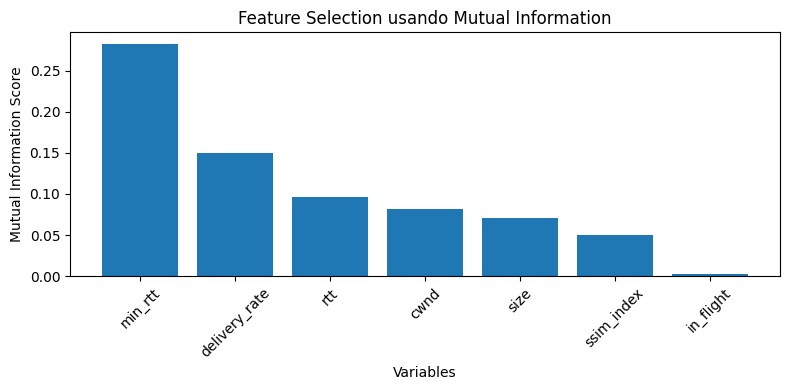

In [25]:
# GRÁFICA DE FEATURE SELECTION

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(feature_scores["feature"], feature_scores["score"])
plt.xticks(rotation=45)
plt.xlabel("Variables")
plt.ylabel("Mutual Information Score")
plt.title("Feature Selection usando Mutual Information")
plt.tight_layout()
plt.show()

In [26]:
# VARIABLES SELECCIONADAS

# A partir del resultado de Mutual Information:
# min_rtt        0.282345
# delivery_rate 0.149650
# rtt            0.096182
# cwnd           0.081676
# size           0.070665
# ssim_index     0.050672
# in_flight      0.002614

# Se elimina "in_flight" porque su aporte casi nulo

selected_features = [
    "min_rtt",
    "delivery_rate",
    "rtt",
    "cwnd",
    "size",
    "ssim_index"
]

print("Variables seleccionadas:")
print(selected_features)

# Crear datasets solo con las variables seleccionadas
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

Variables seleccionadas:
['min_rtt', 'delivery_rate', 'rtt', 'cwnd', 'size', 'ssim_index']
X_train_selected: (62479, 6)
X_test_selected: (15620, 6)


In [27]:
# CREAR MATRICES FINALES ESCALADAS SIN in_flight

selected_idx = [
    list(X.columns).index(col)
    for col in selected_features
]

print("Índices seleccionados:")
print(selected_idx)

X_train_selected_scaled = X_train_scaled[:, selected_idx]
X_test_selected_scaled = X_test_scaled[:, selected_idx]

print("X_train_selected_scaled:", X_train_selected_scaled.shape)
print("X_test_selected_scaled:", X_test_selected_scaled.shape)

Índices seleccionados:
[4, 6, 5, 2, 0, 1]
X_train_selected_scaled: (62479, 6)
X_test_selected_scaled: (15620, 6)


### TSNE

In [28]:
# t-SNE

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# t-SNE puede tardar mucho con datasets grandes. Por eso se usa una muestra estratificada del conjunto de entrenamiento.
# Se usa train para evitar usar información del test en la visualización

X_tsne_sample, _, y_tsne_sample, _ = train_test_split(
    X_train_selected_scaled,
    y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

# Crear el modelo t-SNE para reducir las variables a 2 dimensiones
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

# Ajustar t-SNE sobre la muestra
X_tsne_2d = tsne.fit_transform(X_tsne_sample)

print("t-SNE completado.")
print("Dimensiones:", X_tsne_2d.shape)

t-SNE completado.
Dimensiones: (5000, 2)


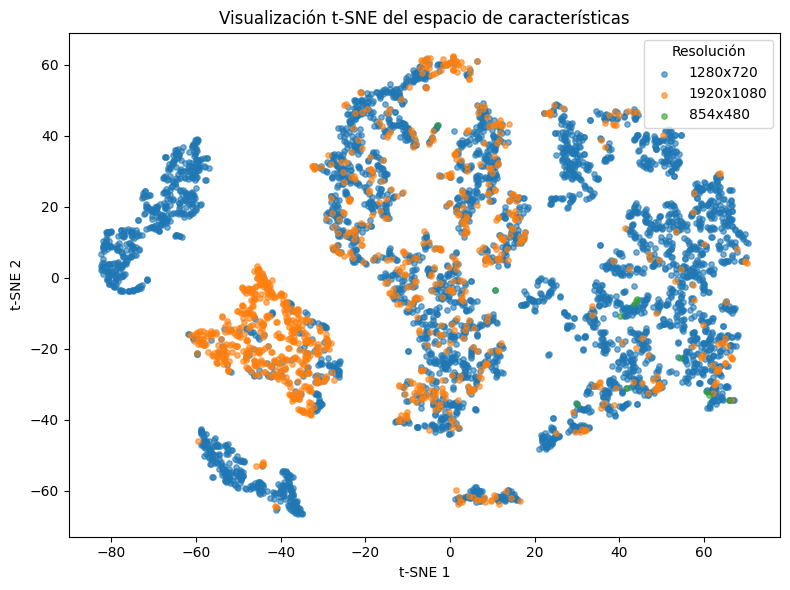

In [29]:
# VISUALIZACIÓN t-SNE

plt.figure(figsize=(8, 6))

# Graficar cada clase con un color diferente
for class_id in np.unique(y_tsne_sample):
    idx = y_tsne_sample == class_id
    
    plt.scatter(
        X_tsne_2d[idx, 0],
        X_tsne_2d[idx, 1],
        label=le.classes_[class_id],
        alpha=0.6,
        s=15
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Visualización t-SNE del espacio de características")
plt.legend(title="Resolución")
plt.tight_layout()
plt.show()

La proyección mediante t-SNE muestra la existencia de agrupamientos en el espacio de características. Se observan regiones donde predominan las resoluciones 1280x720 y 1920x1080, aunque también existe superposición entre clases, indicando que el problema de clasificación no es trivial. La clase 854x480 presenta una representación limitada debido al desbalance del conjunto de datos.

#### Regresion Logística

In [30]:
# LOGISTIC REGRESSION BASE

from sklearn.linear_model import LogisticRegression

# Modelo base
# class_weight='balanced' ayuda a compensar el desbalance de clases.
lr_base = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

# Entrenamiento
lr_base.fit(
    X_train_selected_scaled,
    y_train
)

print("Entrenamiento completado.")

Entrenamiento completado.


In [31]:
# PREDICCIONES

y_pred_lr = lr_base.predict(
    X_test_selected_scaled
)

print("Predicciones completadas.")

Predicciones completadas.


In [32]:
# MÉTRICAS DE CLASIFICACIÓN

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    1280x720       0.87      0.76      0.81     12360
   1920x1080       0.41      0.57      0.47      3224
     854x480       0.11      1.00      0.19        36

    accuracy                           0.72     15620
   macro avg       0.46      0.78      0.49     15620
weighted avg       0.78      0.72      0.74     15620



In [33]:
# ACCURACY

from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print(f"Accuracy: {acc_lr:.4f}")

Accuracy: 0.7226


In [34]:
# F1 MACRO

from sklearn.metrics import f1_score

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="macro"
)

print(f"F1 Macro: {f1_lr:.4f}")

F1 Macro: 0.4933


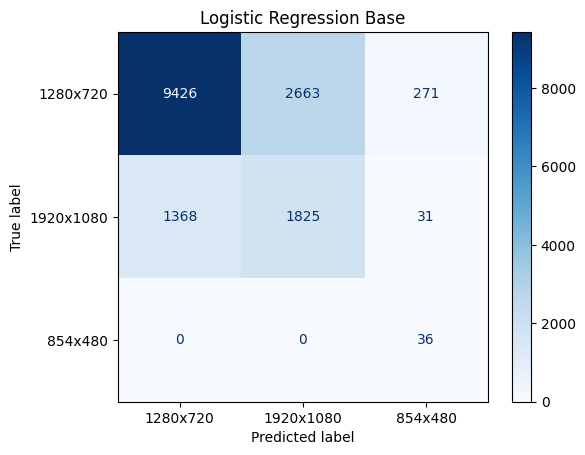

In [35]:
# MATRIZ DE CONFUSIÓN

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Base")
plt.show()

In [36]:
# GUARDAR RESULTADOS DEL MODELO BASE

lr_base_acc = acc_lr
lr_base_f1 = f1_lr

print("Accuracy Base:", lr_base_acc)
print("F1 Macro Base:", lr_base_f1)

Accuracy Base: 0.7225992317541613
F1 Macro Base: 0.4933341069408585


In [43]:
# LOGISTIC REGRESSION + PIPELINE + OPTUNA

import optuna
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score

cv_lr = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

def objective_lr(trial):

    C = trial.suggest_float("C", 1e-4, 100, log=True)

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2"]
    )

    k = trial.suggest_int(
        "k",
        4,
        X_train.shape[1]
    )

    pipe_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(
            score_func=mutual_info_classif,
            k=k
        )),
        ("model", LogisticRegression(
            C=C,
            penalty=penalty,
            solver="saga",
            max_iter=3000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

    scores = cross_val_score(
        pipe_lr,
        X_train,
        y_train,
        cv=cv_lr,
        scoring="f1_macro",
        n_jobs=-1
    )

    return scores.mean()

In [47]:
# EJECUTAR OPTUNA

study_lr = optuna.create_study(direction="maximize")

study_lr.optimize(
    objective_lr,
    n_trials=30
)

print("Mejor F1 Macro CV:", study_lr.best_value)
print("Mejores hiperparámetros:")
print(study_lr.best_params)

[I 2026-06-24 19:31:49,483] A new study created in memory with name: no-name-bdd5f477-2ca0-4f02-bf9d-1079220b1c6f
[I 2026-06-24 19:32:15,065] Trial 0 finished with value: 0.4264026262813374 and parameters: {'C': 0.013326743315974634, 'penalty': 'l1', 'k': 5}. Best is trial 0 with value: 0.4264026262813374.
[I 2026-06-24 19:35:25,685] Trial 1 finished with value: 0.4486296921153657 and parameters: {'C': 0.004949973695682308, 'penalty': 'l2', 'k': 7}. Best is trial 1 with value: 0.4486296921153657.
[I 2026-06-24 19:37:16,213] Trial 2 finished with value: 0.4943855089082961 and parameters: {'C': 10.524989227960598, 'penalty': 'l2', 'k': 7}. Best is trial 2 with value: 0.4943855089082961.
[I 2026-06-24 19:37:24,239] Trial 3 finished with value: 0.20749409057010845 and parameters: {'C': 0.00013470127814479844, 'penalty': 'l1', 'k': 5}. Best is trial 2 with value: 0.4943855089082961.
[I 2026-06-24 19:40:07,793] Trial 4 finished with value: 0.43463533396939535 and parameters: {'C': 0.00669712

Mejor F1 Macro CV: 0.49496756777816575
Mejores hiperparámetros:
{'C': 2.225230849841602, 'penalty': 'l1', 'k': 7}


In [48]:
# ENTRENAR MEJOR PIPELINE LOGISTIC REGRESSION

best_params_lr = study_lr.best_params

pipe_lr_optuna = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(
        score_func=mutual_info_classif,
        k=best_params_lr["k"]
    )),
    ("model", LogisticRegression(
        C=best_params_lr["C"],
        penalty=best_params_lr["penalty"],
        solver="saga",
        max_iter=3000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipe_lr_optuna.fit(X_train, y_train)

y_pred_lr_optuna = pipe_lr_optuna.predict(X_test)

In [49]:
# EVALUACIÓN LOGISTIC REGRESSION + OPTUNA

print(classification_report(
    y_test,
    y_pred_lr_optuna,
    target_names=le.classes_
))

acc_lr_optuna = accuracy_score(y_test, y_pred_lr_optuna)
f1_lr_optuna = f1_score(y_test, y_pred_lr_optuna, average="macro")

print(f"Accuracy LR Optuna: {acc_lr_optuna:.4f}")
print(f"F1 Macro LR Optuna: {f1_lr_optuna:.4f}")

              precision    recall  f1-score   support

    1280x720       0.87      0.76      0.81     12360
   1920x1080       0.41      0.57      0.47      3224
     854x480       0.11      1.00      0.19        36

    accuracy                           0.72     15620
   macro avg       0.46      0.78      0.49     15620
weighted avg       0.78      0.72      0.74     15620

Accuracy LR Optuna: 0.7226
F1 Macro LR Optuna: 0.4929


In [52]:
# LEARNING CURVE - LOGISTIC REGRESSION OPTUNA

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipe_lr_optuna,
    X=X_train,
    y=y_train,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.05, 1.0, 15),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

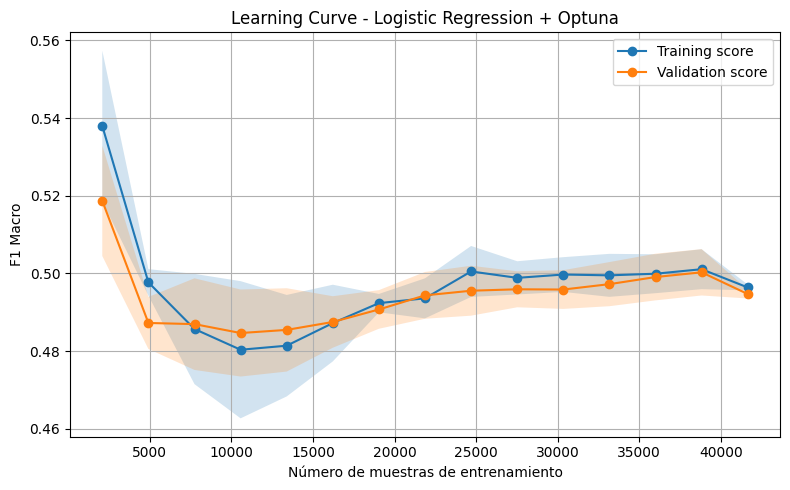

In [53]:
# GRÁFICA LEARNING CURVE LR

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training score"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation score"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("F1 Macro")
plt.title("Learning Curve - Logistic Regression + Optuna")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# RANDOM FOREST BASE

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipe_rf_base = Pipeline([
    
    ("selector", SelectKBest(
        score_func=mutual_info_classif,
        k=7
    )),
    
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

pipe_rf_base.fit(
    X_train,
    y_train
)

print("Random Forest Base entrenado.")

Random Forest Base entrenado.


In [55]:
# PREDICCIONES

y_pred_rf = pipe_rf_base.predict(X_test)

print("Predicciones completadas.")

Predicciones completadas.


In [56]:
# MÉTRICAS

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    1280x720       0.91      0.98      0.95     12360
   1920x1080       0.91      0.65      0.75      3224
     854x480       0.74      0.39      0.51        36

    accuracy                           0.91     15620
   macro avg       0.85      0.67      0.74     15620
weighted avg       0.91      0.91      0.91     15620



In [57]:
# ACCURACY Y F1

acc_rf = accuracy_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

print(f"Accuracy RF Base: {acc_rf:.4f}")
print(f"F1 Macro RF Base: {f1_rf:.4f}")

Accuracy RF Base: 0.9115
F1 Macro RF Base: 0.7365


In [58]:
# GUARDAR RESULTADOS BASE RF

rf_base_acc = acc_rf
rf_base_f1 = f1_rf

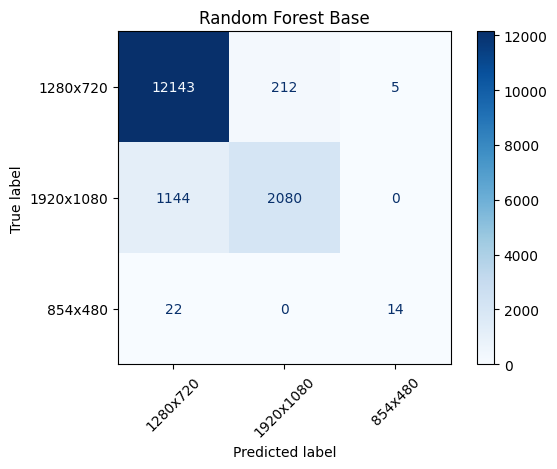

In [59]:
# MATRIZ DE CONFUSIÓN

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Base")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# GUARDAR RESULTADOS RF BASE

rf_base_acc = acc_rf
rf_base_f1 = f1_rf

print("RF Base Accuracy:", rf_base_acc)
print("RF Base F1:", rf_base_f1)

RF Base Accuracy: 0.9114596670934699
RF Base F1: 0.7364607928025096


In [61]:
# RANDOM FOREST + OPTUNA

import optuna

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv_rf = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=1,
    random_state=42
)

def objective_rf(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        400
    )

    max_depth = trial.suggest_int(
        "max_depth",
        5,
        30
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        20
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    k = trial.suggest_int(
        "k",
        4,
        X_train.shape[1]
    )

    pipe_rf = Pipeline([

        ("selector",
         SelectKBest(
             score_func=mutual_info_classif,
             k=k
         )
        ),

        ("model",
         RandomForestClassifier(
             n_estimators=n_estimators,
             max_depth=max_depth,
             min_samples_split=min_samples_split,
             min_samples_leaf=min_samples_leaf,
             class_weight="balanced",
             random_state=42,
             n_jobs=-1
         )
        )

    ])

    scores = cross_val_score(
        pipe_rf,
        X_train,
        y_train,
        scoring="f1_macro",
        cv=cv_rf,
        n_jobs=-1
    )

    return scores.mean()

In [62]:
# EJECUTAR OPTUNA RF

study_rf = optuna.create_study(direction="maximize")

study_rf.optimize(
    objective_rf,
    n_trials=20
)

print("Mejor F1 Macro CV RF:", study_rf.best_value)
print("Mejores hiperparámetros RF:")
print(study_rf.best_params)

[I 2026-06-24 21:32:41,445] A new study created in memory with name: no-name-d0d15250-2d53-4071-81b4-9c021ad8a0b7
[I 2026-06-24 21:32:59,657] Trial 0 finished with value: 0.599914067006444 and parameters: {'n_estimators': 239, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 1, 'k': 7}. Best is trial 0 with value: 0.599914067006444.
[I 2026-06-24 21:33:28,547] Trial 1 finished with value: 0.7683927114243602 and parameters: {'n_estimators': 308, 'max_depth': 26, 'min_samples_split': 15, 'min_samples_leaf': 7, 'k': 7}. Best is trial 1 with value: 0.7683927114243602.
[I 2026-06-24 21:33:55,045] Trial 2 finished with value: 0.7575955670545329 and parameters: {'n_estimators': 268, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 6, 'k': 6}. Best is trial 1 with value: 0.7683927114243602.
[I 2026-06-24 21:34:13,548] Trial 3 finished with value: 0.7633556142086881 and parameters: {'n_estimators': 169, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 7, 'k':

Mejor F1 Macro CV RF: 0.7683927114243602
Mejores hiperparámetros RF:
{'n_estimators': 308, 'max_depth': 26, 'min_samples_split': 15, 'min_samples_leaf': 7, 'k': 7}


In [63]:
# ENTRENAR MEJOR RANDOM FOREST + OPTUNA

best_params_rf = study_rf.best_params

pipe_rf_optuna = Pipeline([
    ("selector", SelectKBest(
        score_func=mutual_info_classif,
        k=best_params_rf["k"]
    )),
    
    ("model", RandomForestClassifier(
        n_estimators=best_params_rf["n_estimators"],
        max_depth=best_params_rf["max_depth"],
        min_samples_split=best_params_rf["min_samples_split"],
        min_samples_leaf=best_params_rf["min_samples_leaf"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf_optuna.fit(X_train, y_train)

y_pred_rf_optuna = pipe_rf_optuna.predict(X_test)

print("Random Forest + Optuna entrenado.")

Random Forest + Optuna entrenado.


In [64]:
# EVALUACIÓN RANDOM FOREST + OPTUNA

print(classification_report(
    y_test,
    y_pred_rf_optuna,
    target_names=le.classes_
))

acc_rf_optuna = accuracy_score(y_test, y_pred_rf_optuna)

f1_rf_optuna = f1_score(
    y_test,
    y_pred_rf_optuna,
    average="macro"
)

print(f"Accuracy RF Optuna: {acc_rf_optuna:.4f}")
print(f"F1 Macro RF Optuna: {f1_rf_optuna:.4f}")

              precision    recall  f1-score   support

    1280x720       0.94      0.92      0.93     12360
   1920x1080       0.73      0.79      0.76      3224
     854x480       0.45      0.78      0.57        36

    accuracy                           0.89     15620
   macro avg       0.71      0.83      0.75     15620
weighted avg       0.90      0.89      0.90     15620

Accuracy RF Optuna: 0.8944
F1 Macro RF Optuna: 0.7549


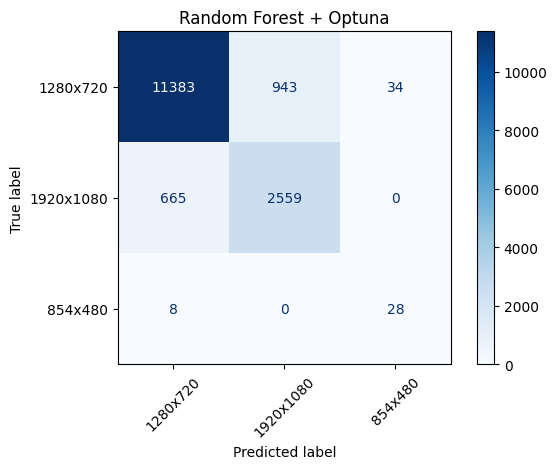

In [65]:
# MATRIZ DE CONFUSIÓN - RANDOM FOREST + OPTUNA

cm_rf_optuna = confusion_matrix(
    y_test,
    y_pred_rf_optuna
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_optuna,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest + Optuna")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
# LEARNING CURVE - RANDOM FOREST + OPTUNA

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipe_rf_optuna,
    X=X_train,
    y=y_train,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.05, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

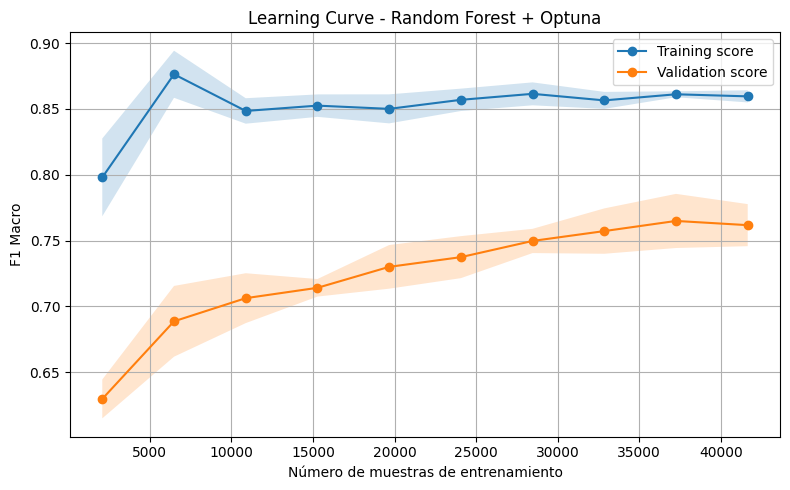

In [67]:
# GRÁFICA LEARNING CURVE RF

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training score"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation score"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("F1 Macro")
plt.title("Learning Curve - Random Forest + Optuna")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
# COMPARACIÓN ESTADÍSTICA

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from scipy.stats import wilcoxon

cv_compare = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

In [69]:
# SCORES LOGISTIC REGRESSION

scores_lr = cross_val_score(
    pipe_lr_optuna,
    X,
    y,
    cv=cv_compare,
    scoring="f1_macro",
    n_jobs=-1
)

print(scores_lr)
print("Media LR:", scores_lr.mean())

[0.4875401  0.49615559 0.48798369 0.49786571 0.49248174 0.49423309
 0.49851174 0.48661416 0.48863941 0.49911407]
Media LR: 0.492913931240994


In [70]:
# SCORES RANDOM FOREST

scores_rf = cross_val_score(
    pipe_rf_optuna,
    X,
    y,
    cv=cv_compare,
    scoring="f1_macro",
    n_jobs=-1
)

print(scores_rf)
print("Media RF:", scores_rf.mean())

[0.75059504 0.77306834 0.77801669 0.78166319 0.748795   0.77342858
 0.74385363 0.78389297 0.76595193 0.75869049]
Media RF: 0.7657955864356238


In [71]:
# TEST DE WILCOXON

stat, p_value = wilcoxon(
    scores_lr,
    scores_rf
)

print("Wilcoxon statistic:", stat)
print("p-value:", p_value)

Wilcoxon statistic: 0.0
p-value: 0.001953125


In [72]:
# INTERPRETACIÓN

alpha = 0.05

if p_value < alpha:
    print(
        "Se rechaza H0. Existe diferencia estadísticamente significativa entre los modelos."
    )
else:
    print(
        "No se puede rechazar H0. No existe diferencia estadísticamente significativa."
    )

Se rechaza H0. Existe diferencia estadísticamente significativa entre los modelos.


### Referencias

#### Referencias de conceptos

[1] C. M. Bishop, Pattern Recognition and Machine Learning. New York, NY, USA: Springer, 2006.

[2] T. Hastie, R. Tibshirani, and J. Friedman, The Elements of Statistical Learning, 2nd ed. New York, NY, USA: Springer, 2009.

[3] L. Breiman, “Random forests,” Machine Learning, vol. 45, no. 1, pp. 5–32, 2001.

[4] F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” Journal of Machine Learning Research, vol. 12, pp. 2825–2830, 2011.

[5] T. Akiba et al., “Optuna: A Next-generation Hyperparameter Optimization Framework,” Proc. ACM SIGKDD, pp. 2623–2631, 2019.

#### Referencias de código

[6] Scikit-learn Developers, “Scikit-learn Documentation,” 2025. [Online]. Available: https://scikit-learn.org

[7] Optuna Developers, “Optuna Documentation,” 2025. [Online]. Available: https://optuna.org

[8] L. van der Maaten and G. Hinton, “Visualizing Data using t-SNE,” Journal of Machine Learning Research, vol. 9, pp. 2579–2605, 2008.

#### Prompt del código

In [ ]:
# Prompt ChatGPT:
# Implementar t-SNE para visualización de clases utilizando las variables seleccionadas después de Feature Selection

In [ ]:
# Prompt ChatGPT:
# Implementar Logistic Regression Base utilizando sklearn, métricas Accuracy, F1 Macro y matriz de confusión

In [ ]:
# Prompt ChatGPT:
# Implementar Random Forest con optimización de hiperparámetros mediante Optuna

### Conclusiones

# Conclusiones

- Se implementó un sistema de clasificación multiclase capaz de predecir la resolución de video a partir de variables asociadas a las condiciones de red y características de los segmentos de video. El problema fue abordado utilizando tres clases de resolución: 854x480, 1280x720 y 1920x1080.

- El análisis exploratorio reveló un gran desbalance de clases, siendo 1280x720 la resolución predominante. Debido a ello, se utilizó F1 Macro como métrica principal de evaluación, ya que permite valorar el desempeño de manera equilibrada entre todas las clases.

- La etapa de selección de características mostró que las variables más informativas para la predicción fueron min_rtt, delivery_rate, rtt, cwnd, size y ssim_index, mientras que in_flight presentó una contribución prácticamente nula al proceso de clasificación.

- La visualización mediante t-SNE evidenció la existencia de agrupamientos y una separación parcial entre clases, indicando que la información disponible contiene patrones útiles para la discriminación de resoluciones, aunque existe cierto nivel de superposición entre ellas.

- Logistic Regression obtuvo un desempeño limitado, alcanzando un Accuracy aproximado de 72% y un F1 Macro cercano a 0.49. La optimización de hiperparámetros mediante Optuna no produjo mejoras significativas, lo que sugiere que las relaciones presentes en los datos no pueden ser representadas adecuadamente mediante fronteras de decisión lineales.

- Random Forest superó ampliamente a Logistic Regression. El modelo base alcanzó un Accuracy de 91.15% y un F1 Macro de 0.7365, demostrando una mejor capacidad para capturar relaciones no lineales entre las variables.

- La optimización de Random Forest mediante Optuna incrementó el F1 Macro hasta 0.7549, mejorando especialmente la detección de la clase minoritaria 854x480. Aunque el Accuracy disminuyó ligeramente, la mejora en F1 Macro indica un comportamiento más equilibrado entre las tres clases.

- El mejor modelo obtenido fue Random Forest optimizado con Optuna, el cual logró el mayor desempeño global y mostró una mejor capacidad para manejar el desbalance existente en el conjunto de datos.

- Las curvas de aprendizaje mostraron que Logistic Regression alcanzó rápidamente su límite de desempeño, mientras que Random Forest continuó beneficiándose del incremento de datos de entrenamiento, evidenciando una mayor capacidad de aprendizaje y generalización.

- Como trabajo futuro, se recomienda incorporar variables temporales adicionales, explorar modelos secuenciales basados en redes neuronales recurrentes o Transformers y evaluar la predicción de la siguiente resolución dentro de un esquema completo de Adaptive Bitrate Streaming (ABR), más cercano a un entorno real de operación.
